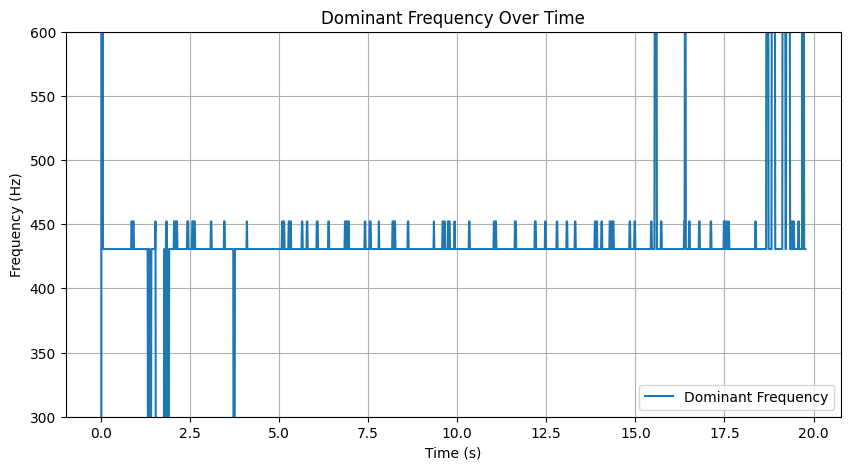

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load an audio file
filename = "/content/Record (online-voice-recorder.com) (2).mp3"  # Change to your file (MP4, WAV, etc.)
y, sr = librosa.load(filename, sr=None)  # Load with original sampling rate

# Compute the Short-Time Fourier Transform (STFT)
D = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))  # STFT magnitude

# Get the corresponding frequency values
frequencies = librosa.fft_frequencies(sr=sr, n_fft=2048)

# Find the dominant frequency at each time step
dominant_frequencies = frequencies[np.argmax(D, axis=0)]

# Get time values
time_values = librosa.times_like(dominant_frequencies, sr=sr, hop_length=512)

# Plot the dominant frequency over time
plt.figure(figsize=(10, 5))
plt.plot(time_values, dominant_frequencies, label="Dominant Frequency")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Dominant Frequency Over Time")
plt.legend()
plt.ylim(300, 600)
plt.grid()
plt.show()

<ipython-input-3-d9bf36d0c825>:14: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')


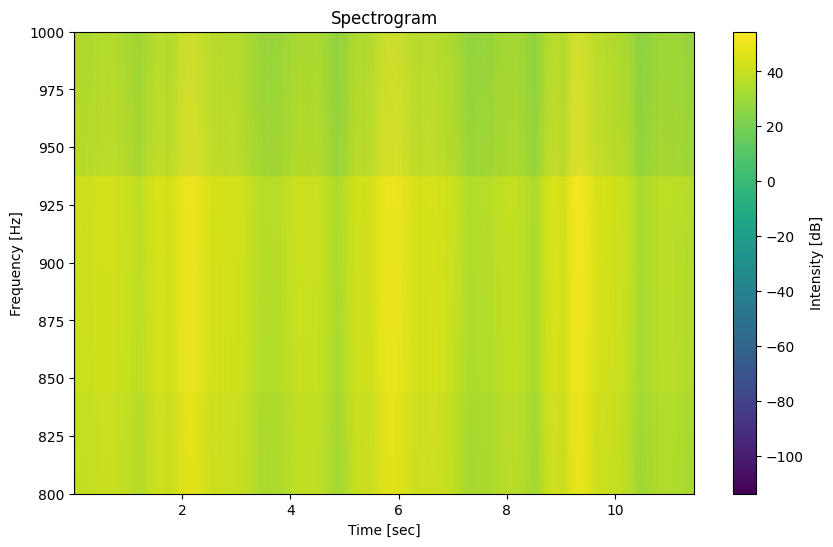

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy.io.wavfile import read

# Load the audio file
sample_rate, signal = read("/content/Voix 004.wav")

# Compute the spectrogram
f, t, Sxx = spectrogram(signal, fs=sample_rate)

# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram')
plt.colorbar(label='Intensity [dB]')
plt.ylim(800, 1000)
plt.show()

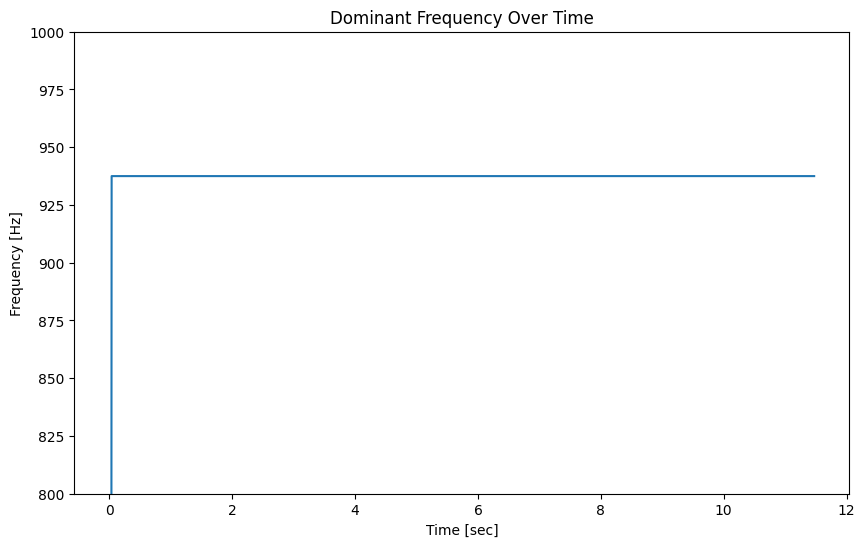

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy.io.wavfile import read

# Load the audio file
sample_rate, signal = read("/content/Voix 004.wav")

# Compute the spectrogram
f, t, Sxx = spectrogram(signal, fs=sample_rate)

# Find the dominant frequency at each time step
dominant_frequencies = f[np.argmax(Sxx, axis=0)]

# Plot the dominant frequency over time
plt.figure(figsize=(10, 6))
plt.plot(t, dominant_frequencies)
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Dominant Frequency Over Time')
plt.ylim(800, 1000)  # Adjust y-axis limits if needed
plt.show()